In [1]:
# importing libraries
import time
import numpy as np
import matplotlib.pyplot as plt

### Homework 2

Problem 3, part c

In [5]:
def func_f(x):
    return x * np.exp(-x)

def acceptance_rejection(lam, c, N = 10_000):
    # initializing variables
    accepted_samples = []
    total_proposals = 0
    start_time = time.time()
    
    while len(accepted_samples) < N:
        
        u = np.random.uniform(0, 1)
        x = -np.log(1 - u) / lam
        total_proposals += 1
        
        v = np.random.uniform(0, 1)
        
        if lam == 1/2:
            threshold = (e / 2) * x * np.exp(-x / 2)
        else: 
            prop_g = lam * np.exp(-lam * x)
            threshold = func_f(x) / (c * prop_g)
            
        if v < threshold:
            accepted_samples.append(x)
        
    end_time = time.time()
    
    empirical_rate = N / total_proposals
    elapsed_time = end_time - start_time
    mean_time = elapsed_time / N
    
    return np.array(accepted_samples), empirical_rate, mean_time

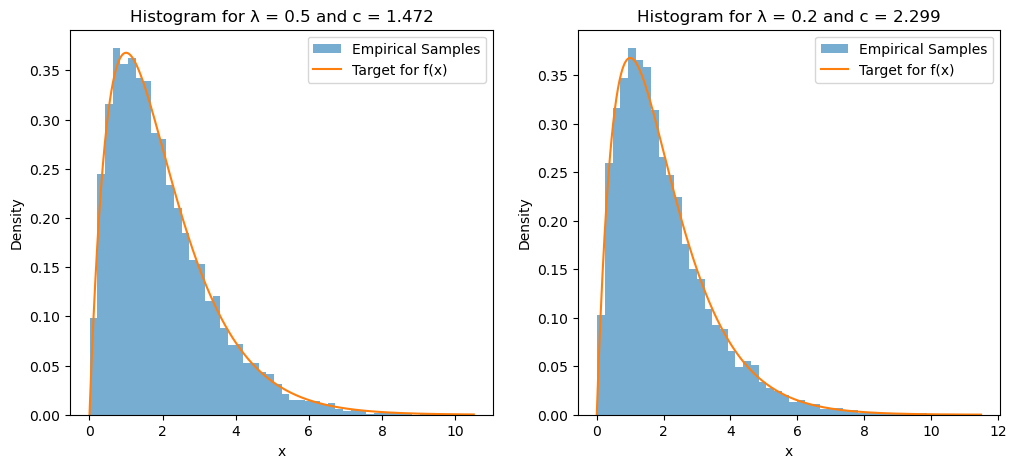

In [15]:
e = np.e

# case 1: 
    # lambda = 0.5, c = 4/e
# case 2:
    # lambda = 0.2, c = 1/(0.16*e)
    
parameters = {
    "Case 1: λ = 0.5": {"lam": 0.5, "c": 4 / e},
    "Case 1: λ = 0.2": {"lam": 0.2, "c": 1/(0.16*e)}
}

plt.figure(figsize = (12, 5))

for i, (label, p) in enumerate(parameters.items(), 1):
    lam, c = p['lam'], p['c']
    theoretical_rate = 1 / c
    
    samples, emp_rate, mean_time = acceptance_rejection(lam, c, N = 10_000)
    
    plt.subplot(1, 2, i)
    plt.hist(samples, bins = 50, density = True, alpha = 0.6, label = 'Empirical Samples')
    
    x_vals = np.linspace(0, max(samples), 1000)
    plt.plot(x_vals, func_f(x_vals), label = 'Target for f(x)')
             
    plt.title(f"Histogram for λ = {lam} and c = {c:.3f}")
    plt.xlabel('x')
    plt.ylabel('Density')
    plt.legend()
       
plt.show()